In [1]:
# CELL 1 — Install Dependencies

!pip install transformers datasets evaluate scikit-learn sentencepiece -q


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2 — Imports

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    brier_score_loss
)

from scipy.spatial.distance import mahalanobis
from scipy.special import softmax
from tqdm import tqdm

torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [3]:
# CELL 3 — Load AG News

dataset = load_dataset("ag_news")

train_ds = dataset["train"].shuffle(seed=42).select(range(12000))
test_ds = dataset["test"].shuffle(seed=42).select(range(3000))

print(train_ds[0])

{'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.', 'label': 0}


In [4]:
# CELL 4 — Load Tokenizer

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

In [5]:
# CELL 5 — Tokenization

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

columns = ["input_ids", "attention_mask", "label"]

train_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

Map: 100%|██████████| 3000/3000 [00:00<00:00, 3210.96 examples/s]


In [7]:
# CELL 6 — Load Model

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [8]:
# CELL 7 — Metrics Function

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "macro_f1": f1
    }

In [10]:
# CELL 8 — Training Arguments

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="no",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    fp16=torch.cuda.is_available()
)

C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [11]:
# CELL 9 — Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

In [12]:
# CELL 10 — Train Model

trainer.train()

  7%|▋         | 101/1500 [00:59<03:29,  6.67it/s]

{'loss': 0.5557, 'grad_norm': 1.5372014045715332, 'learning_rate': 4.6733333333333335e-05, 'epoch': 0.13}


 13%|█▎        | 201/1500 [01:11<02:31,  8.60it/s]

{'loss': 0.3693, 'grad_norm': 6.83806037902832, 'learning_rate': 4.3433333333333336e-05, 'epoch': 0.27}


 20%|██        | 301/1500 [01:23<02:19,  8.58it/s]

...

100%|██████████| 1500/1500 [03:47<00:00,  8.66it/s]

{'loss': 0.1428, 'grad_norm': 6.7031073570251465, 'learning_rate': 1.0000000000000001e-07, 'epoch': 2.0}


                                                   
100%|██████████| 1500/1500 [03:52<00:00,  6.45it/s]

{'eval_loss': 0.2500920593738556, 'eval_accuracy': 0.924, 'eval_macro_f1': 0.9238508838245983, 'eval_runtime': 5.2265, 'eval_samples_per_second': 573.999, 'eval_steps_per_second': 35.971, 'epoch': 2.0}
{'train_runtime': 233.1945, 'train_samples_per_second': 102.918, 'train_steps_per_second': 6.432, 'train_loss': 0.25947419420878093, 'epoch': 2.0}


TrainOutput(global_step=1500, training_loss=0.25947419420878093, metrics={'train_runtime': 233.1945, 'train_samples_per_second': 102.918, 'train_steps_per_second': 6.432, 'total_flos': 794832740352000.0, 'train_loss': 0.25947419420878093, 'epoch': 2.0})

In [13]:
# CELL 11 — Evaluate

trainer.evaluate()

100%|██████████| 188/188 [00:06<00:00, 29.52it/s]


{'eval_loss': 0.2500920593738556,
 'eval_accuracy': 0.924,
 'eval_macro_f1': 0.9238508838245983,
 'eval_runtime': 6.6104,
 'eval_samples_per_second': 453.829,
 'eval_steps_per_second': 28.44,
 'epoch': 2.0}

In [14]:
# CELL 12 — Get Predictions + CLS Embeddings

from torch.utils.data import DataLoader

model.eval()

test_loader = DataLoader(
    test_ds,
    batch_size=32
)

all_logits = []
all_labels = []
all_cls = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        logits = model.classifier(
            model.pre_classifier(cls_embeddings)
        )

        all_logits.append(
            logits.cpu().numpy()
        )

        all_labels.append(
            labels.cpu().numpy()
        )

        all_cls.append(
            cls_embeddings.cpu().numpy()
        )

all_logits = np.vstack(all_logits)
all_labels = np.concatenate(all_labels)
all_cls = np.vstack(all_cls)

print(all_logits.shape)
print(all_cls.shape)

100%|██████████| 94/94 [00:10<00:00,  8.59it/s]

(3000, 4)
(3000, 768)


In [15]:
# CELL 13 — Softmax Confidence

probs = softmax(all_logits, axis=1)

confidences = probs.max(axis=1)

predictions = probs.argmax(axis=1)

accuracy = np.mean(predictions == all_labels)

print("Test Accuracy:", accuracy)
print("Mean Confidence:", confidences.mean())

Test Accuracy: 0.9246666666666666
Mean Confidence: 0.9763104


In [16]:
# Cell 14 Compute Mahalanobis Statistics

train_loader = DataLoader(
    train_ds,
    batch_size=32
)

train_cls = []

model.eval()

with torch.no_grad():

    for batch in tqdm(train_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        train_cls.append(
            cls_embeddings.cpu().numpy()
        )

train_cls = np.vstack(train_cls)

print(train_cls.shape)

100%|██████████| 375/375 [00:43<00:00,  8.69it/s]

(12000, 768)


In [17]:
# CELL 15 — Mean + Covariance

mean_vec = np.mean(train_cls, axis=0)

cov = np.cov(train_cls, rowvar=False)

cov += 1e-5 * np.eye(cov.shape[0])

inv_cov = np.linalg.inv(cov)

print(mean_vec.shape)
print(cov.shape)

(768,)
(768, 768)


In [19]:
# CELL 16 — Mahalanobis Drift Scores

drift_scores = []

for emb in tqdm(all_cls):

    d = mahalanobis(
        emb,
        mean_vec,
        inv_cov
    )

    drift_scores.append(d)

drift_scores = np.array(drift_scores)

print("Mean Drift:", drift_scores.mean())
print("Max Drift:", drift_scores.max())

100%|██████████| 3000/3000 [00:00<00:00, 5954.53it/s]

Mean Drift: 27.682683776132613
Max Drift: 119.2942109456107


In [20]:
# CELL 17 — Normalize Drift

drift_norm = (
    drift_scores - drift_scores.min()
) / (
    drift_scores.max() - drift_scores.min()
)

print(drift_norm[:10])

[0.1762393  0.17457381 0.05878806 0.17131251 0.06568363 0.22886316
 0.10034314 0.08439081 0.10849817 0.15931316]


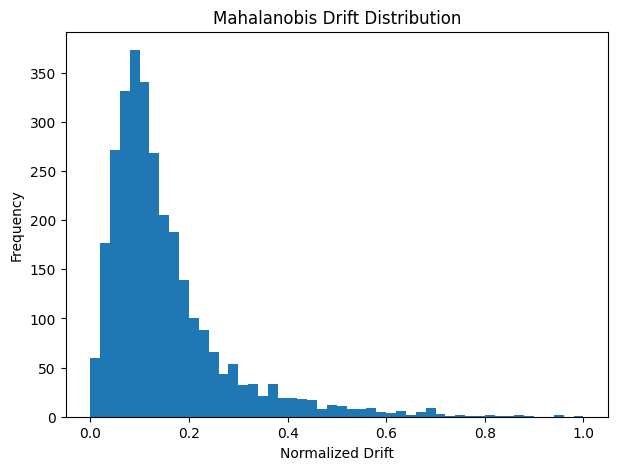

In [22]:
# CELL 18 — Plot Drift Distribution

plt.figure(figsize=(7,5))

plt.hist(
    drift_norm,
    bins=50
)

plt.xlabel("Normalized Drift")
plt.ylabel("Frequency")
plt.title("Mahalanobis Drift Distribution")

plt.show()

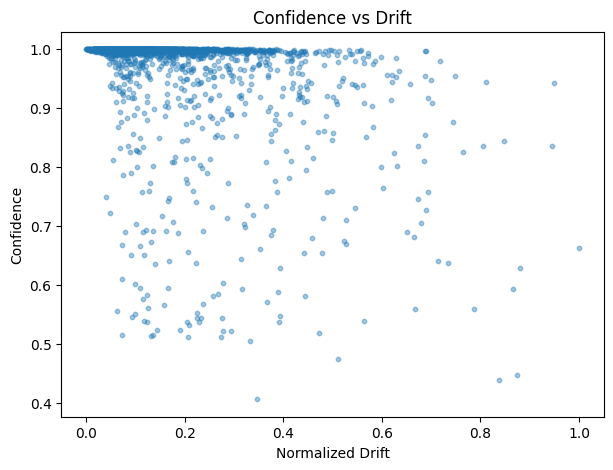

In [23]:
# CELL 19 — Confidence vs Drift

plt.figure(figsize=(7,5))

plt.scatter(
    drift_norm,
    confidences,
    alpha=0.4,
    s=10
)

plt.xlabel("Normalized Drift")
plt.ylabel("Confidence")
plt.title("Confidence vs Drift")

plt.show()

In [24]:
# CELL 20 — Correlation Analysis

corr = np.corrcoef(
    drift_norm,
    confidences
)[0,1]

print("Drift-Confidence Correlation:", corr)


Drift-Confidence Correlation: -0.3783614953774744


In [25]:
# CELL 21 — Baseline Confidence Thresholding

threshold = 0.90

baseline_keep = confidences >= threshold

baseline_coverage = baseline_keep.mean()

baseline_acc = np.mean(
    predictions[baseline_keep] ==
    all_labels[baseline_keep]
)

print("Baseline Coverage:", baseline_coverage)
print("Baseline Selective Accuracy:", baseline_acc)

Baseline Coverage: 0.9333333333333333
Baseline Selective Accuracy: 0.9492857142857143


In [26]:
# CELL 22 — Drift-Aware Robustness Score

alpha = 2.0

robustness_score = np.exp(
    -alpha * drift_norm
)

print(robustness_score[:10])

[0.70294361 0.705289   0.88907284 0.70990435 0.87689567 0.63272062
 0.81816907 0.84469335 0.80493291 0.72714722]


In [27]:
# CELL 23 — Drift-Aware Confidence

dasc_confidence = (
    confidences * robustness_score
)

print(dasc_confidence[:10])

[0.70122103 0.70417322 0.88885201 0.70887199 0.87610952 0.34021331
 0.81766326 0.843853   0.78155475 0.71250439]


In [28]:
# CELL 24 — DASC Selective Prediction

dasc_threshold = 0.70

dasc_keep = dasc_confidence >= dasc_threshold

dasc_coverage = dasc_keep.mean()

dasc_acc = np.mean(
    predictions[dasc_keep] ==
    all_labels[dasc_keep]
)

print("DASC Coverage:", dasc_coverage)
print("DASC Selective Accuracy:", dasc_acc)

DASC Coverage: 0.7096666666666667
DASC Selective Accuracy: 0.9671207139502114


In [30]:
# CELL 25 — Compare Abstention Rates

print("Total Samples:", len(all_labels))

print("\nBaseline Abstained:",
      np.sum(~baseline_keep))

print("DASC Abstained:",
      np.sum(~dasc_keep))

Total Samples: 3000

Baseline Abstained: 200
DASC Abstained: 871


In [31]:
# CELL 26 — Risk-Coverage Function

def risk_coverage_curve(scores,
                        predictions,
                        labels):

    order = np.argsort(scores)[::-1]

    risks = []
    coverages = []

    n = len(labels)

    for k in range(100, n, 100):

        idx = order[:k]

        acc = np.mean(
            predictions[idx] == labels[idx]
        )

        risk = 1 - acc

        coverage = k / n

        risks.append(risk)
        coverages.append(coverage)

    return coverages, risks

In [33]:
# CELL 27 — Baseline Risk-Coverage

base_cov, base_risk = risk_coverage_curve(
    confidences,
    predictions,
    all_labels
)

In [34]:
# CELL 28 — DASC Risk-Coverage

dasc_cov, dasc_risk = risk_coverage_curve(
    dasc_confidence,
    predictions,
    all_labels
)

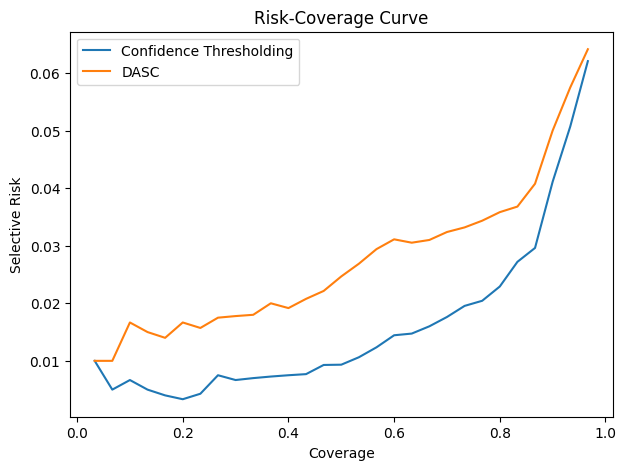

In [35]:
# CELL 29 — Plot Risk-Coverage Curves

plt.figure(figsize=(7,5))

plt.plot(
    base_cov,
    base_risk,
    label="Confidence Thresholding"
)

plt.plot(
    dasc_cov,
    dasc_risk,
    label="DASC"
)

plt.xlabel("Coverage")
plt.ylabel("Selective Risk")
plt.title("Risk-Coverage Curve")

plt.legend()

plt.show()

In [36]:
# CELL 30 — Compute AURC

def compute_aurc(coverages, risks):

    area = 0.0

    for i in range(1, len(coverages)):

        dx = coverages[i] - coverages[i-1]

        avg_height = (
            risks[i] + risks[i-1]
        ) / 2

        area += dx * avg_height

    return area

base_aurc = compute_aurc(
    base_cov,
    base_risk
)

dasc_aurc = compute_aurc(
    dasc_cov,
    dasc_risk
)

print("Baseline AURC:", base_aurc)
print("DASC AURC:", dasc_aurc)

Baseline AURC: 0.014129563563396945
DASC AURC: 0.025162571198227273


In [37]:
# CELL 31 — Alpha Sweep

alphas = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

results = []

for alpha in alphas:

    robustness_score = np.exp(
        -alpha * drift_norm
    )

    dasc_scores = (
        confidences * robustness_score
    )

    cov, risk = risk_coverage_curve(
        dasc_scores,
        predictions,
        all_labels
    )

    aurc = compute_aurc(cov, risk)

    keep = dasc_scores >= 0.70

    coverage = keep.mean()

    selective_acc = np.mean(
        predictions[keep] ==
        all_labels[keep]
    )

    results.append([
        alpha,
        coverage,
        selective_acc,
        aurc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "alpha",
        "coverage",
        "selective_accuracy",
        "AURC"
    ]
)

results_df

,alpha,coverage,selective_accuracy,AURC
0,0.1,0.969000,0.936705,0.016366
1,0.3,0.961333,0.939320,0.019141
2,0.5,0.950333,0.942827,0.020441
3,0.7,0.927667,0.948257,0.021712
4,1.0,0.888667,0.955364,0.022870
5,1.5,0.808667,0.963314,0.024091
6,2.0,0.709667,0.967121,0.025163


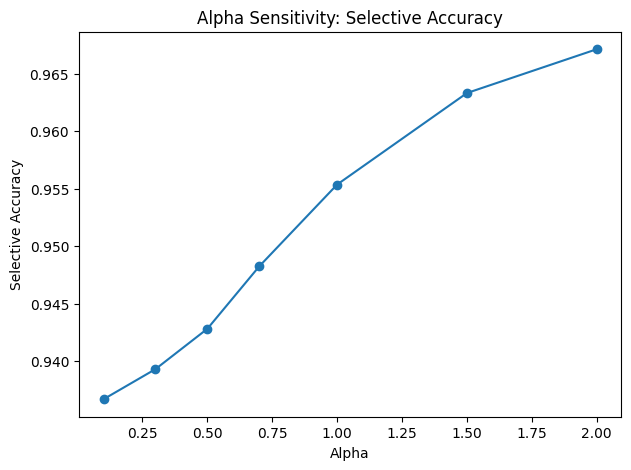

In [38]:
# CELL 32 — Plot Alpha vs Accuracy

plt.figure(figsize=(7,5))

plt.plot(
    results_df["alpha"],
    results_df["selective_accuracy"],
    marker="o"
)

plt.xlabel("Alpha")
plt.ylabel("Selective Accuracy")
plt.title("Alpha Sensitivity: Selective Accuracy")

plt.show()

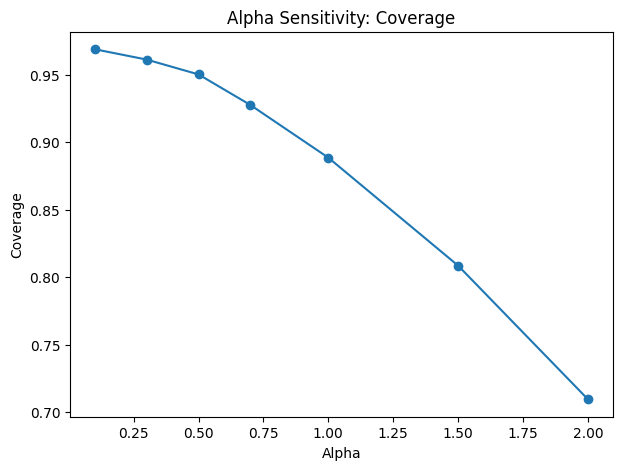

In [39]:
# CELL 33 — Plot Alpha vs Coverage

plt.figure(figsize=(7,5))

plt.plot(
    results_df["alpha"],
    results_df["coverage"],
    marker="o"
)

plt.xlabel("Alpha")
plt.ylabel("Coverage")
plt.title("Alpha Sensitivity: Coverage")

plt.show()

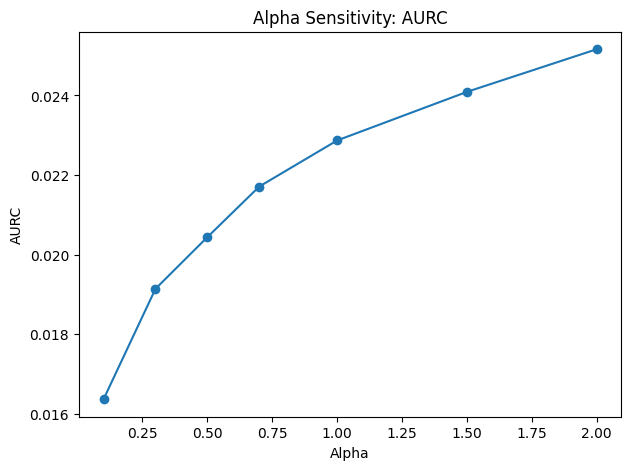

In [40]:
# CELL 34 — Plot Alpha vs AURC

plt.figure(figsize=(7,5))

plt.plot(
    results_df["alpha"],
    results_df["AURC"],
    marker="o"
)

plt.xlabel("Alpha")
plt.ylabel("AURC")
plt.title("Alpha Sensitivity: AURC")

plt.show()

In [41]:
# CELL 35 — Load Yahoo Answers

yahoo = load_dataset(
    "yahoo_answers_topics"
)

ood_ds = yahoo["test"].shuffle(seed=42).select(range(3000))

print(ood_ds[0])

{'id': 3493, 'topic': 4, 'question_title': 'Is the registered version of  REGISTRY MECHANIC worth paying for?', 'question_content': 'Or is  the free version good enough?', 'best_answer': 'D E F I N I T E L Y !!! I happened across Registry Mechanic 5 in Wal Mart one day. I spent 60 dollars on it and would do it again in a heartbeat. This software is easy to use and extremely effective. G O  F O R  I T !!!'}


In [42]:
# CELL 36 — Tokenize OOD Data

def merge_text(example):

    text = (
        str(example["question_title"]) + " " +
        str(example["question_content"]) + " " +
        str(example["best_answer"])
    )

    return {"text": text}

ood_ds = ood_ds.map(merge_text)

ood_ds = ood_ds.map(
    tokenize,
    batched=True
)

ood_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask"
    ]
)

Map: 100%|██████████| 3000/3000 [00:00<00:00, 11809.12 examples/s]


In [43]:
# CELL 37 — Extract OOD Embeddings + Logits

ood_loader = DataLoader(
    ood_ds,
    batch_size=32
)

ood_logits = []
ood_cls = []

model.eval()

with torch.no_grad():

    for batch in tqdm(ood_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        logits = model.classifier(
            model.pre_classifier(cls_embeddings)
        )

        ood_logits.append(
            logits.cpu().numpy()
        )

        ood_cls.append(
            cls_embeddings.cpu().numpy()
        )

ood_logits = np.vstack(ood_logits)
ood_cls = np.vstack(ood_cls)

print(ood_logits.shape)
print(ood_cls.shape)

100%|██████████| 94/94 [00:10<00:00,  8.56it/s]

(3000, 4)
(3000, 768)


In [44]:
# CELL 38 — OOD Confidence

ood_probs = softmax(
    ood_logits,
    axis=1
)

ood_confidences = ood_probs.max(axis=1)

print("OOD Mean Confidence:",
      ood_confidences.mean())

OOD Mean Confidence: 0.9106418


In [45]:
# CELL 39 — OOD Drift Scores

ood_drift = []

for emb in tqdm(ood_cls):

    d = mahalanobis(
        emb,
        mean_vec,
        inv_cov
    )

    ood_drift.append(d)

ood_drift = np.array(ood_drift)

ood_drift_norm = (
    ood_drift - drift_scores.min()
) / (
    drift_scores.max() - drift_scores.min()
)

print("OOD Mean Drift:",
      ood_drift_norm.mean())

100%|██████████| 3000/3000 [00:00<00:00, 6568.97it/s]

OOD Mean Drift: 0.4569870545102205


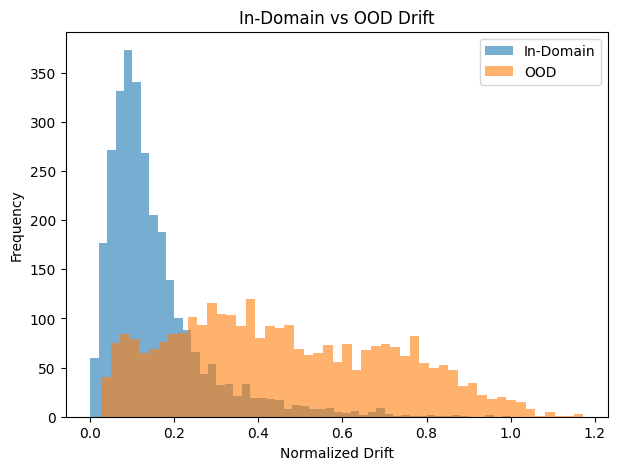

In [46]:
# CELL 40 — Compare Drift Distributions

plt.figure(figsize=(7,5))

plt.hist(
    drift_norm,
    bins=50,
    alpha=0.6,
    label="In-Domain"
)

plt.hist(
    ood_drift_norm,
    bins=50,
    alpha=0.6,
    label="OOD"
)

plt.xlabel("Normalized Drift")
plt.ylabel("Frequency")
plt.title("In-Domain vs OOD Drift")

plt.legend()

plt.show()

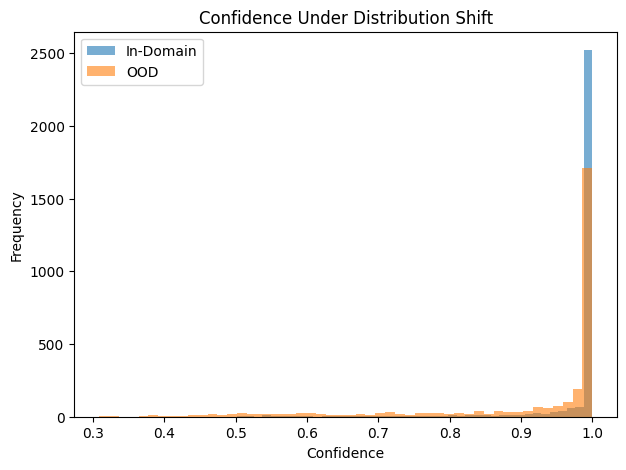

In [47]:
# CELL 41 — Compare Confidence Distributions

plt.figure(figsize=(7,5))

plt.hist(
    confidences,
    bins=50,
    alpha=0.6,
    label="In-Domain"
)

plt.hist(
    ood_confidences,
    bins=50,
    alpha=0.6,
    label="OOD"
)

plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Under Distribution Shift")

plt.legend()

plt.show()

In [48]:
# CELL 42 — OOD Robustness Scores

alpha = 0.5

ood_robustness = np.exp(
    -alpha * ood_drift_norm
)

ood_dasc_scores = (
    ood_confidences * ood_robustness
)

print(ood_dasc_scores[:10])

[0.91316579 0.93792707 0.564581   0.37126422 0.90974732 0.64921724
 0.41561179 0.89810972 0.68369332 0.85145144]


In [49]:
# CELL 43 — OOD Abstention Rate

threshold = 0.70

ood_keep = (
    ood_dasc_scores >= threshold
)

ood_coverage = ood_keep.mean()

ood_abstention = 1 - ood_coverage

print("OOD Coverage:", ood_coverage)
print("OOD Abstention Rate:", ood_abstention)

OOD Coverage: 0.6753333333333333
OOD Abstention Rate: 0.32466666666666666


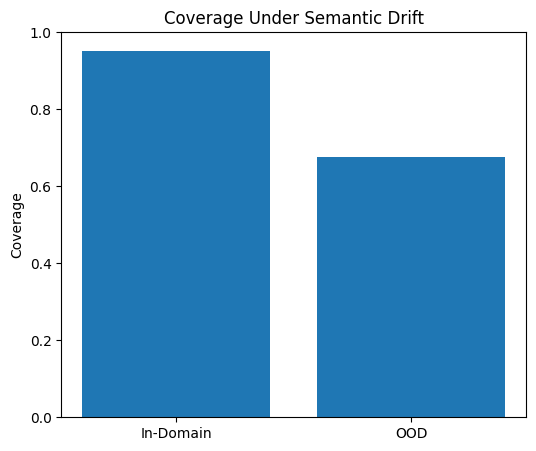

In [50]:
# CELL 44 — Compare In-Domain vs OOD Coverage

id_keep = (
    (confidences * np.exp(-0.5 * drift_norm))
    >= threshold
)

id_coverage = id_keep.mean()

plt.figure(figsize=(6,5))

labels = ["In-Domain", "OOD"]

values = [
    id_coverage,
    ood_coverage
]

plt.bar(labels, values)

plt.ylabel("Coverage")
plt.title("Coverage Under Semantic Drift")

plt.ylim(0,1)

plt.show()

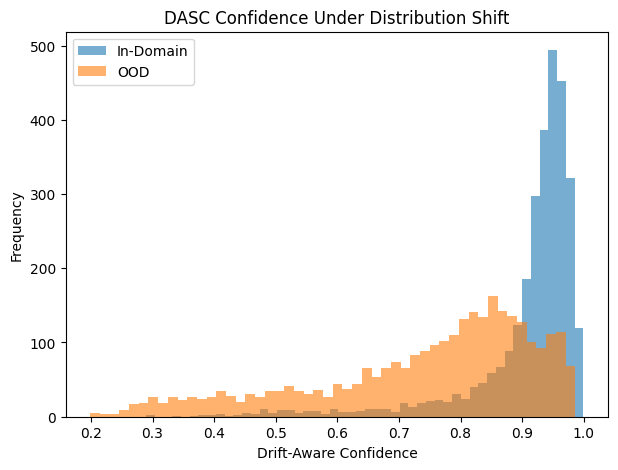

In [51]:
# CELL 45 — Compare Drift-Aware Confidence

plt.figure(figsize=(7,5))

plt.hist(
    confidences * np.exp(-0.5 * drift_norm),
    bins=50,
    alpha=0.6,
    label="In-Domain"
)

plt.hist(
    ood_dasc_scores,
    bins=50,
    alpha=0.6,
    label="OOD"
)

plt.xlabel("Drift-Aware Confidence")
plt.ylabel("Frequency")
plt.title("DASC Confidence Under Distribution Shift")

plt.legend()

plt.show()

In [52]:
# CELL 46 - final summary table

summary_results = pd.DataFrame({

    "Method": [
        "Confidence Thresholding",
        "DASC (α=0.1)",
        "DASC (α=0.5)",
        "DASC (α=1.0)",
        "DASC (α=2.0)"
    ],

    "Coverage": [
        baseline_coverage,
        results_df.loc[
            results_df["alpha"] == 0.1,
            "coverage"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 0.5,
            "coverage"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 1.0,
            "coverage"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 2.0,
            "coverage"
        ].values[0]
    ],

    "Selective Accuracy": [
        baseline_acc,

        results_df.loc[
            results_df["alpha"] == 0.1,
            "selective_accuracy"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 0.5,
            "selective_accuracy"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 1.0,
            "selective_accuracy"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 2.0,
            "selective_accuracy"
        ].values[0]
    ],

    "AURC": [
        base_aurc,

        results_df.loc[
            results_df["alpha"] == 0.1,
            "AURC"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 0.5,
            "AURC"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 1.0,
            "AURC"
        ].values[0],

        results_df.loc[
            results_df["alpha"] == 2.0,
            "AURC"
        ].values[0]
    ]
})

summary_results = summary_results.round(4)

summary_results

,Method,Coverage,Selective Accuracy,AURC
0,Confidence Thresholding,0.9333,0.9493,0.0141
1,DASC (α=0.1),0.9690,0.9367,0.0164
2,DASC (α=0.5),0.9503,0.9428,0.0204
3,DASC (α=1.0),0.8887,0.9554,0.0229
4,DASC (α=2.0),0.7097,0.9671,0.0252
